In [3]:
#!/usr/bin/env python3
"""
ts_forecast_from_scalograms_fast.py

Fast comparative forecasting from saved scalograms (.npy in scalograms/<modality>/).

- Balanced sampling: exactly K files per CONDITION
- Early thinning: optional frequency crop + cap time columns + stride-decimate columns
- PCA over frequency bins (fit on train-only), target = PC1
- Windows: X (seq_len × N_FEAT), y (horizon)
- Models: Naive, ARIMA (single-fit fast), LSTM, GRU, CNN-LSTM
- Prints a clear "[INFO] Starting neural model training..." line before NN training begins

Run:
  python ts_forecast_from_scalograms_fast.py
"""

import os, glob
from pathlib import Path
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ==================== KNOBS (speed/size) ====================
SCALOGRAM_ROOT = "scalograms"
MODALITIES = ["acoustic", "vibration"]

# Balanced sampling
FILES_PER_CONDITION = 4      # exactly this many per condition

# Time axis throttling
MAX_TIME_COLS_PER_FILE = 20000   # cap T per file (None = keep full)
COL_STRIDE = 8                   # keep every Nth column (>=1)

# Frequency throttling (rows)
FREQ_SLICE = (None, 128)         # (start, end) on freq axis; (None, None) keeps all

# PCA features from frequency axis
N_FEAT = 8
EPS = 1e-12

# Supervised framing
SEQ_LEN  = 64
HORIZON  = 8
STEP     = 8

# Splits (chronological by time)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15  # rest = test

# Deep training
EPOCHS       = 8
BATCH_SIZE   = 128
LR           = 1e-3
HIDDEN_SIZE  = 64
NUM_LAYERS   = 1
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

# Repro & threading
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(max(1, os.cpu_count() // 2))

In [4]:
# ==================== HELPERS ====================
def _parse_condition_from_fname(npy_path: str) -> str:
    """
    Expect names like: <load>_<condition>_<severity>__... e.g. 0Nm_BPFI_03__values__win00010.npy
    Also fixes 'Unbalalnce' -> 'Unbalance'.
    """
    stem = Path(npy_path).stem
    main = stem.split("__")[0]  # "0Nm_BPFI_03"
    parts = main.split("_")
    cond = parts[1] if len(parts) >= 2 else "UNKNOWN"
    return "Unbalance" if cond.lower() == "unbalalnce" else cond

def scan_balanced_per_condition(modality: str, k_per_cond: int) -> List[str]:
    """
    Return up to k_per_cond scalogram files per condition for a given modality.
    """
    folder = os.path.join(SCALOGRAM_ROOT, modality)
    all_paths = sorted(glob.glob(os.path.join(folder, "*.npy")))
    if not all_paths:
        return []
    from collections import defaultdict
    groups = defaultdict(list)
    for p in all_paths:
        cond = _parse_condition_from_fname(p)
        groups[cond].append(p)
    rng = np.random.default_rng(SEED)
    selected = []
    for cond, paths in groups.items():
        rng.shuffle(paths)
        selected.extend(paths[:k_per_cond])
    rng.shuffle(selected)
    return selected

def load_power(path: str) -> np.ndarray:
    arr = np.load(path, allow_pickle=False)
    if arr.ndim != 2:
        raise ValueError(f"Scalogram must be 2D (F,T): {path}")
    return arr.astype(np.float32)

def normalize_log(power: np.ndarray) -> np.ndarray:
    X = np.log10(power + EPS).astype(np.float32)
    mn, mx = X.min(), X.max()
    if mx > mn:
        X = (X - mn) / (mx - mn)
    else:
        X.fill(0.0)
    return X

def concat_time_matrix(paths: List[str]) -> np.ndarray:
    """
    Load multiple scalograms (F,T), apply freq crop, time cap, time stride, normalize,
    and concatenate along time axis -> (F, sumT).
    """
    chunks = []
    fs, fe = FREQ_SLICE
    for p in paths:
        try:
            P = load_power(p)  # (F,T)
            if fs is not None or fe is not None:
                P = P[slice(fs, fe), :]
            if MAX_TIME_COLS_PER_FILE and P.shape[1] > MAX_TIME_COLS_PER_FILE:
                P = P[:, :MAX_TIME_COLS_PER_FILE]
            if COL_STRIDE and COL_STRIDE > 1:
                P = P[:, ::COL_STRIDE]
            P = normalize_log(P)
            chunks.append(P)
        except Exception as e:
            print(f"[WARN] skip {Path(p).name}: {e}")
    if not chunks:
        raise RuntimeError("No valid scalograms loaded.")
    F = chunks[0].shape[0]
    for c in chunks:
        if c.shape[0] != F:
            raise ValueError("Inconsistent frequency-bin count across files. Ensure consistent generation settings.")
    return np.concatenate(chunks, axis=1)

def chrono_split_time(P: np.ndarray):
    """
    Split P (F,T) chronologically by time axis into train/val/test.
    """
    T = P.shape[1]
    n_train = int(T * TRAIN_FRAC)
    n_val   = int(T * (TRAIN_FRAC + VAL_FRAC))
    return P[:, :n_train], P[:, n_train:n_val], P[:, n_val:], n_train, n_val, T - n_val

def build_supervised(X_feat: np.ndarray, y_uni: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    X_feat: (T, N_FEAT)
    y_uni:  (T,)
    Returns:
      X: (N, SEQ_LEN, N_FEAT)
      y: (N, HORIZON)
    """
    N = X_feat.shape[0]
    Xs, Ys = [], []
    end = N - (SEQ_LEN + HORIZON) + 1
    for i in range(0, max(0, end), STEP):
        Xs.append(X_feat[i:i+SEQ_LEN, :])
        Ys.append(y_uni[i+SEQ_LEN:i+SEQ_LEN+HORIZON])
    if not Xs:
        return np.zeros((0, SEQ_LEN, X_feat.shape[1]), np.float32), np.zeros((0, HORIZON), np.float32)
    return np.stack(Xs).astype(np.float32), np.stack(Ys).astype(np.float32)

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
def mae(a, b):  return float(mean_absolute_error(a, b))
def mape(a, b):
    denom = np.maximum(np.abs(a), 1e-8)
    return float(np.mean(np.abs((a - b)/denom)))*100.0


=== ACOUSTIC from scalograms ===
Loaded 12 files -> matrix 128×19200 (F×T)
Windows -> train=1672  val=352  test=352
[INFO] Starting neural model training (LSTM/GRU/CNN-LSTM)...
[LSTMForecaster] ep 01  train=0.15686  val=0.18336
[LSTMForecaster] ep 02  train=0.12350  val=0.09221
[LSTMForecaster] ep 03  train=0.04597  val=0.04514
[LSTMForecaster] ep 04  train=0.03107  val=0.03878
[LSTMForecaster] ep 05  train=0.02894  val=0.03826
[LSTMForecaster] ep 06  train=0.02824  val=0.03750
[LSTMForecaster] ep 07  train=0.02784  val=0.03738
[LSTMForecaster] ep 08  train=0.02771  val=0.04049
[GRUForecaster] ep 01  train=0.14763  val=0.15846
[GRUForecaster] ep 02  train=0.09877  val=0.05751
[GRUForecaster] ep 03  train=0.03724  val=0.04332
[GRUForecaster] ep 04  train=0.02973  val=0.03782
[GRUForecaster] ep 05  train=0.02753  val=0.03608
[GRUForecaster] ep 06  train=0.02718  val=0.03575
[GRUForecaster] ep 07  train=0.02719  val=0.03567
[GRUForecaster] ep 08  train=0.02673  val=0.03554
[CNNLSTMForeca

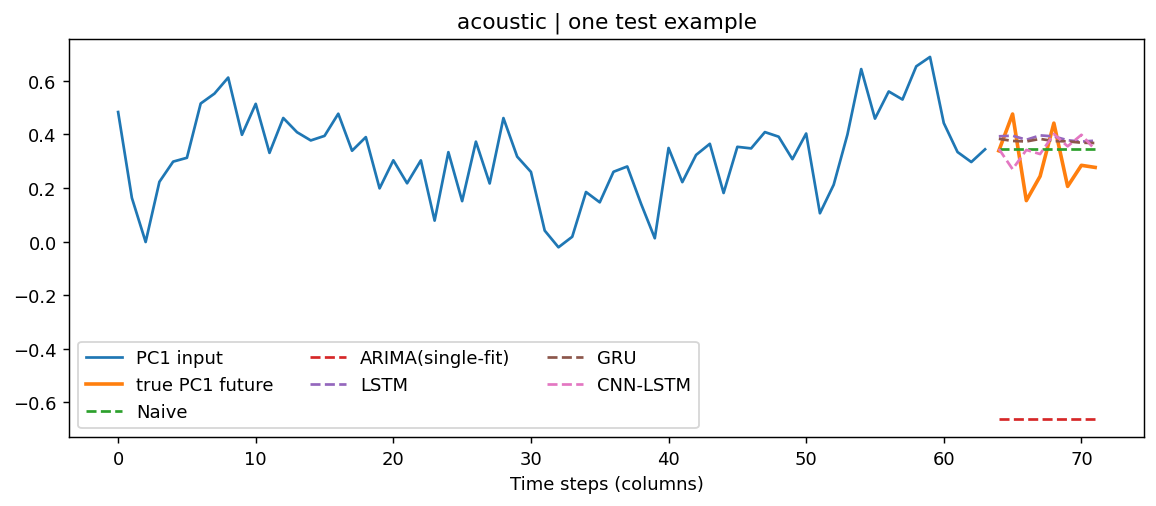


=== VIBRATION from scalograms ===
Loaded 20 files -> matrix 128×32000 (F×T)
Windows -> train=2792  val=592  test=592
[INFO] Starting neural model training (LSTM/GRU/CNN-LSTM)...
[LSTMForecaster] ep 01  train=0.09515  val=0.07933
[LSTMForecaster] ep 02  train=0.03943  val=0.02497
[LSTMForecaster] ep 03  train=0.02142  val=0.02037
[LSTMForecaster] ep 04  train=0.02042  val=0.02020
[LSTMForecaster] ep 05  train=0.02029  val=0.01995
[LSTMForecaster] ep 06  train=0.02017  val=0.02012
[LSTMForecaster] ep 07  train=0.02010  val=0.01987
[LSTMForecaster] ep 08  train=0.02018  val=0.02023
[GRUForecaster] ep 01  train=0.09338  val=0.06862
[GRUForecaster] ep 02  train=0.03668  val=0.02476
[GRUForecaster] ep 03  train=0.02153  val=0.02063
[GRUForecaster] ep 04  train=0.02035  val=0.02019
[GRUForecaster] ep 05  train=0.02029  val=0.02037
[GRUForecaster] ep 06  train=0.02009  val=0.01963
[GRUForecaster] ep 07  train=0.02004  val=0.01972
[GRUForecaster] ep 08  train=0.01993  val=0.01977
[CNNLSTMForec

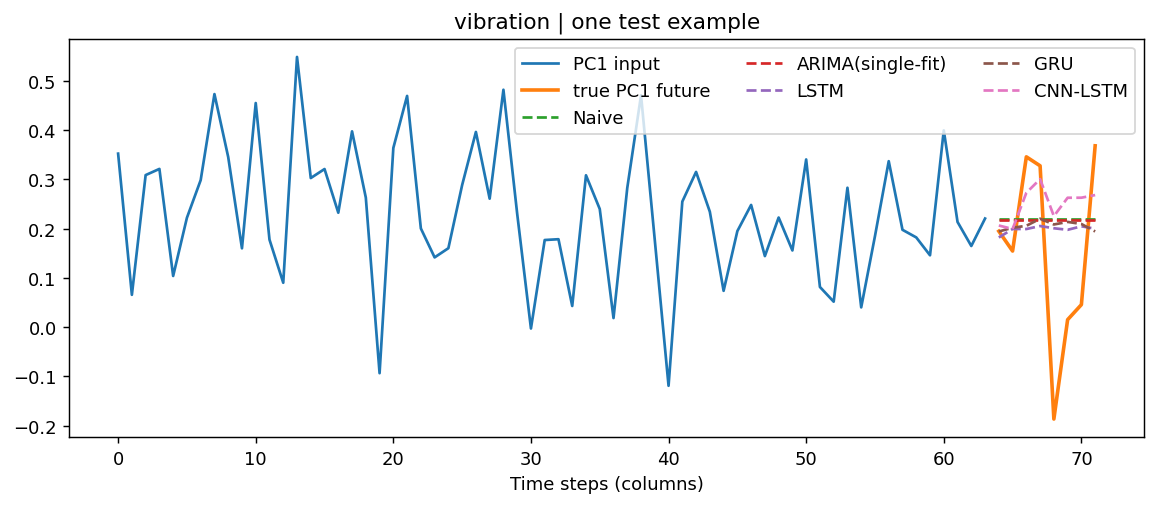

In [5]:
# ==================== DATASETS ====================
class SeqDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.from_numpy(self.y[i])

# ==================== MODELS ====================
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden=64, layers=1, horizon=1):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x):
        out, _ = self.rnn(x)    # (B,T,H)
        return self.head(out[:, -1, :])

class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden=64, layers=1, horizon=1):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])

class CNNLSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden=64, layers=1, horizon=1,
                 conv_channels=64, kernel_size=5, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Conv1d(input_size, conv_channels, kernel_size, padding=pad)
        self.bn   = nn.BatchNorm1d(conv_channels)
        self.act  = nn.ReLU()
        self.do   = nn.Dropout(dropout)
        self.rnn  = nn.LSTM(conv_channels, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x):
        x = x.transpose(1, 2)           # (B,F,T)
        x = self.do(self.act(self.bn(self.conv(x))))
        x = x.transpose(1, 2)           # (B,T,Cc)
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :])

# ==================== TRAIN / INFER ====================
def train_model(model, dl_tr, dl_va, epochs=8, lr=1e-3, device="cpu"):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    best = None; best_val = float("inf"); patience=3; wait=0
    for ep in range(1, epochs+1):
        model.train(); run=0.0; n=0
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); pred = model(xb)
            loss = crit(pred, yb); loss.backward(); opt.step()
            run += loss.item()*xb.size(0); n += xb.size(0)
        tr = run/max(1,n)

        model.eval(); run=0.0; n=0
        with torch.no_grad():
            for xb, yb in dl_va:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb); loss = crit(pred, yb)
                run += loss.item()*xb.size(0); n += xb.size(0)
        va = run/max(1,n)
        print(f"[{model.__class__.__name__}] ep {ep:02d}  train={tr:.5f}  val={va:.5f}")

        if va < best_val - 1e-6:
            best_val = va; best = {k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait += 1
            if wait >= patience:
                print("  early stop"); break
    if best is not None: model.load_state_dict(best)
    return model

def infer_model(model, X, device="cpu"):
    model.eval(); outs=[]
    with torch.no_grad():
        for i in range(0, len(X), 1024):
            xb = torch.from_numpy(X[i:i+1024]).to(device)
            outs.append(model(xb).cpu().numpy())
    return np.vstack(outs) if outs else np.zeros((0, X.shape[1]))

def naive_forecast(Xte, horizon):
    last_pc1 = Xte[:, -1, 0:1]
    return np.repeat(last_pc1, horizon, axis=1)

# ==================== FAST ARIMA (single fit) ====================
def arima_single_fit_forecasts(y_train: np.ndarray, len_val: int, len_test: int, total_extra: int) -> np.ndarray:
    """
    Fit ARIMA ONCE to y_train and forecast a long sequence:
      length = len_val + len_test + total_extra
    Returns array of that length. We will slice windows' horizons out of this vector.
    """
    order_candidates = [(1,0,0), (1,1,0), (2,0,0), (2,1,0)]
    best_fit = None; best_aic = float("inf")
    for order in order_candidates:
        try:
            r = ARIMA(y_train, order=order).fit(method_kwargs={"warn_convergence": False})
            if r.aic < best_aic:
                best_aic = r.aic; best_fit = r
        except Exception:
            continue
    if best_fit is None:
        best_fit = ARIMA(y_train, order=(1,0,0)).fit(method_kwargs={"warn_convergence": False})

    steps = len_val + len_test + total_extra
    long_fcst = best_fit.forecast(steps=steps)  # from end of train
    return np.asarray(long_fcst, dtype=np.float32)

def arima_slice_windows_from_long_fcst(long_fcst: np.ndarray, len_val: int, seq_len: int, horizon: int, n_test_windows: int) -> np.ndarray:
    """
    Map the precomputed long forecast to each test window's horizon:
      For test window i (0-indexed), the horizon starts at: offset = len_val + seq_len + i
    """
    preds = np.zeros((n_test_windows, horizon), dtype=np.float32)
    for i in range(n_test_windows):
        start = len_val + seq_len + i
        end   = start + horizon
        if end <= len(long_fcst):
            preds[i, :] = long_fcst[start:end]
        else:
            # pad by repeating last element if forecast too short
            tail = long_fcst[start:] if start < len(long_fcst) else np.array([long_fcst[-1]], dtype=np.float32)
            fill = np.full(horizon - len(tail), tail[-1], dtype=np.float32)
            preds[i, :] = np.concatenate([tail, fill])
    return preds

# ==================== CORE PIPELINE ====================
def run_modality(modality: str):
    print(f"\n=== {modality.upper()} from scalograms ===")
    paths = scan_balanced_per_condition(modality, FILES_PER_CONDITION)
    if not paths:
        print(f"[WARN] no scalograms in {SCALOGRAM_ROOT}/{modality}")
        return

    # Build (F,T) after early thinning
    P = concat_time_matrix(paths)          # (F, T_total)
    F, T = P.shape
    print(f"Loaded {len(paths)} files -> matrix {F}×{T} (F×T)")

    # Chrono split on time
    Ptr, Pva, Pte, ntr, nva, nte = chrono_split_time(P)

    # PCA on train-only (freq->features per time-slice)
    pca = PCA(n_components=min(N_FEAT, F), random_state=SEED)
    pca.fit(Ptr.T)

    Xtr = pca.transform(Ptr.T).astype(np.float32)
    Xva = pca.transform(Pva.T).astype(np.float32)
    Xte = pca.transform(Pte.T).astype(np.float32)

    # Target = PC1
    ytr = Xtr[:, 0]
    yva = Xva[:, 0]
    yte = Xte[:, 0]

    # Supervised windows
    Xtr_w, Ytr_w = build_supervised(Xtr, ytr)
    Xva_w, Yva_w = build_supervised(Xva, yva)
    Xte_w, Yte_w = build_supervised(Xte, yte)
    print(f"Windows -> train={len(Xtr_w)}  val={len(Xva_w)}  test={len(Xte_w)}")

    if len(Xte_w) == 0:
        print("Not enough test windows. Reduce SEQ_LEN/HORIZON or relax caps.")
        return

    results = []

    # Naive baseline
    yhat_naive = naive_forecast(Xte_w, HORIZON)
    results.append(("Naive", yhat_naive))

    # ---------- ARIMA (single-fit, fast) ----------
    # Fit once on ytr, forecast over (len(yva) + len(yte) + seq_len + horizon),
    # then slice horizons per test window.
    long_fcst = arima_single_fit_forecasts(ytr, len(yva), len(yte), total_extra=SEQ_LEN + HORIZON)
    yhat_arima = arima_slice_windows_from_long_fcst(long_fcst, len(yva), SEQ_LEN, HORIZON, n_test_windows=len(Xte_w))
    results.append(("ARIMA(single-fit)", yhat_arima))

    # ---------- Neural nets ----------
    print("[INFO] Starting neural model training (LSTM/GRU/CNN-LSTM)...")  # <- requested print

    dl_tr = DataLoader(SeqDataset(Xtr_w, Ytr_w), batch_size=BATCH_SIZE, shuffle=True)
    dl_va = DataLoader(SeqDataset(Xva_w, Yva_w), batch_size=BATCH_SIZE, shuffle=False)

    # LSTM
    lstm = LSTMForecaster(Xtr_w.shape[2], HIDDEN_SIZE, NUM_LAYERS, HORIZON)
    lstm = train_model(lstm, dl_tr, dl_va, EPOCHS, LR, DEVICE)
    yhat_lstm = infer_model(lstm, Xte_w, DEVICE)
    results.append(("LSTM", yhat_lstm))

    # GRU
    gru = GRUForecaster(Xtr_w.shape[2], HIDDEN_SIZE, NUM_LAYERS, HORIZON)
    gru = train_model(gru, dl_tr, dl_va, EPOCHS, LR, DEVICE)
    yhat_gru = infer_model(gru, Xte_w, DEVICE)
    results.append(("GRU", yhat_gru))

    # CNN-LSTM
    cnnlstm = CNNLSTMForecaster(Xtr_w.shape[2], HIDDEN_SIZE, NUM_LAYERS, HORIZON,
                                conv_channels=HIDDEN_SIZE, kernel_size=5, dropout=0.1)
    cnnlstm = train_model(cnnlstm, dl_tr, dl_va, EPOCHS, LR, DEVICE)
    yhat_cnnlstm = infer_model(cnnlstm, Xte_w, DEVICE)
    results.append(("CNN-LSTM", yhat_cnnlstm))

    # ---------- Evaluate ----------
    def eval_preds(name, pred, Y):
        y_true_flat = Y.reshape(-1); y_pred_flat = pred.reshape(-1)
        print(f"  {name:>15s} | H1  RMSE={rmse(Y[:,0], pred[:,0]):.4f}  MAE={mae(Y[:,0], pred[:,0]):.4f}  MAPE={mape(Y[:,0], pred[:,0]):.2f}%"
              f"   | ALL  RMSE={rmse(y_true_flat, y_pred_flat):.4f}  MAE={mae(y_true_flat, y_pred_flat):.4f}  MAPE={mape(y_true_flat, y_pred_flat):.2f}%")

    print("\nTEST performance (target=PC1):")
    for name, pred in results:
        eval_preds(name, pred, Yte_w)

    # ---------- Plot one test example ----------
    idx = len(Xte_w)//2
    t_base = np.arange(SEQ_LEN); t_fut = np.arange(SEQ_LEN, SEQ_LEN+HORIZON)
    plt.figure(figsize=(9,4), dpi=130)
    plt.plot(t_base, Xte_w[idx,:,0], label="PC1 input")
    plt.plot(t_fut,  Yte_w[idx],     label="true PC1 future", linewidth=2)
    for name, pred in results:
        plt.plot(t_fut, pred[idx], '--', label=name)
    plt.title(f"{modality} | one test example")
    plt.xlabel("Time steps (columns)")
    plt.legend(ncol=3); plt.tight_layout(); plt.show()

# ==================== MAIN ====================
def main():
    for mod in MODALITIES:
        try:
            run_modality(mod)
        except Exception as e:
            print(f"[WARN] Skipping {mod}: {e}")

if __name__ == "__main__":
    main()


In [1]:
#!/usr/bin/env python3
"""
png_scalogram_classify_balanced_split.py

- Loads scalogram PNGs from: scalograms/<modality>/pngs/*.png
- Ensures *enough* samples per condition by taking up to TARGET_PER_CONDITION per condition per modality
- Does a stratified (by condition) train/val/test split: 70% / 15% / 15%
- Trains & compares: SVM, DBN-like (RBM+LR), ELM, BPNN, AE+LR, CNN (multitask), LSTM (multitask)
"""

import os, glob, random
from pathlib import Path
from typing import List, Tuple, Dict
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neural_network import BernoulliRBM

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- CONFIG --------------------
SCALOGRAM_ROOT = "scalograms"
MODALITIES = ["acoustic", "vibration"]
PNG_SUBFOLDER = "pngs"

# Take *at least* this many per CONDITION per MODALITY (if available).
# If a condition has fewer PNGs, we take all available for that condition.
TARGET_PER_CONDITION = 24

IMG_SIZE = (128, 128)     # (H, W) resize for models

# Classical ML dims
PCA_DIM = 64

# Torch training
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS_CNN  = 8
EPOCHS_LSTM = 8
EPOCHS_AE   = 10
BATCH_SIZE  = 16
LR          = 1e-3

# Repro
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

# -------------------- DATA LOADING --------------------
def parse_labels_from_name(name: str) -> Tuple[str, str, str]:
    """
    Returns (load, condition, severity) parsed from filename stem.
    Example stem: '0Nm_BPFI_03__values__win00010'
    """
    main = name.split("__")[0]
    parts = main.split("_")
    load = parts[0] if len(parts) > 0 else "UNK"
    condition = parts[1] if len(parts) > 1 else "UNK"
    if condition.lower() == "unbalalnce":
        condition = "Unbalance"
    severity = parts[2] if len(parts) > 2 else "UNK"
    return load, condition, severity

def list_pngs_for_modality(modality: str) -> List[str]:
    folder = os.path.join(SCALOGRAM_ROOT, modality, PNG_SUBFOLDER)
    return sorted(glob.glob(os.path.join(folder, "*.png")))

def select_up_to_target_per_condition(k: int) -> List[Tuple[str, str, str, str]]:
    """
    Return list of (path, modality, condition, severity),
    selecting up to k images per condition per modality (take all if <k).
    """
    from collections import defaultdict
    rng = np.random.default_rng(RANDOM_SEED)
    selected: List[Tuple[str, str, str, str]] = []

    for mod in MODALITIES:
        paths = list_pngs_for_modality(mod)
        if not paths:
            continue
        by_cond = defaultdict(list)
        for p in paths:
            stem = Path(p).stem
            _, cond, sev = parse_labels_from_name(stem)
            by_cond[cond].append((p, mod, cond, sev))

        for cond, items in by_cond.items():
            rng.shuffle(items)
            take = items[:k] if len(items) >= k else items  # take all if fewer than k
            selected.extend(take)

    # mix modalities/conditions a bit
    rng.shuffle(selected)
    return selected

def load_image_gray(path: str, size=(128, 128)) -> np.ndarray:
    img = Image.open(path).convert("L").resize(size, Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr  # (H, W)

# -------------------- DATASET --------------------
class ImageDataset(Dataset):
    def __init__(self, X_imgs, cond_ids, sev_ids):
        self.X = X_imgs                      # (N, 1, H, W)
        self.yc = cond_ids.astype(np.int64)  # (N,)
        self.ys = sev_ids.astype(np.int64)   # (N,)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (
            torch.from_numpy(self.X[i]),
            torch.tensor(self.yc[i], dtype=torch.long),
            torch.tensor(self.ys[i], dtype=torch.long),
        )

# -------------------- MODELS --------------------
class SmallCNN(nn.Module):
    def __init__(self, n_cond: int, n_sev: int):
        super().__init__()
        self.fe = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4))
        )
        self.flat = nn.Flatten()
        self.fc_cond = nn.Linear(64*4*4, n_cond)
        self.fc_sev  = nn.Linear(64*4*4, n_sev)
    def forward(self, x):
        z = self.fe(x)
        z = self.flat(z)
        return self.fc_cond(z), self.fc_sev(z)

class ColumnLSTM(nn.Module):
    """
    Treat image columns as a time sequence: T = W, features = H.
    Input to LSTM: (B, T, H)
    """
    def __init__(self, img_h: int, hidden: int, n_cond: int, n_sev: int, layers=1):
        super().__init__()
        self.rnn = nn.LSTM(input_size=img_h, hidden_size=hidden, num_layers=layers, batch_first=True)
        self.fc_cond = nn.Linear(hidden, n_cond)
        self.fc_sev  = nn.Linear(hidden, n_sev)
    def forward(self, x):
        # x: (B, 1, H, W) -> (B, W, H)
        x = x.squeeze(1).transpose(1, 2)
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.fc_cond(last), self.fc_sev(last)

class SimpleAE(nn.Module):
    def __init__(self, img_h: int, img_w: int, bottleneck=64):
        super().__init__()
        d = img_h * img_w
        self.enc = nn.Sequential(
            nn.Linear(d, 512), nn.ReLU(),
            nn.Linear(512, bottleneck)
        )
        self.dec = nn.Sequential(
            nn.Linear(bottleneck, 512), nn.ReLU(),
            nn.Linear(512, d), nn.Sigmoid()
        )
        self.img_h, self.img_w = img_h, img_w
    def forward(self, x):
        z = x.view(x.size(0), -1)
        code = self.enc(z)
        recon = self.dec(code).view(x.size(0), 1, self.img_h, self.img_w)
        return code, recon

# ELM (Extreme Learning Machine)
class ELM:
    def __init__(self, in_dim, hidden_dim=512, alpha=1e-2, activation="tanh", n_classes=None, seed=42):
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.alpha = alpha
        self.activation = activation
        self.n_classes = n_classes
        self.rng = np.random.default_rng(seed)
        self.W = None; self.b = None; self.beta = None
    def _act(self, X):
        return np.maximum(0, X) if self.activation == "relu" else np.tanh(X)
    def fit(self, X, y):
        self.W = self.rng.standard_normal((self.in_dim, self.hidden_dim)).astype(np.float32) * 0.5
        self.b = self.rng.standard_normal((self.hidden_dim,)).astype(np.float32) * 0.1
        H = self._act(X @ self.W + self.b)
        y_onehot = np.eye(self.n_classes, dtype=np.float32)[y]
        I = np.eye(self.hidden_dim, dtype=np.float32)
        self.beta = np.linalg.solve(H.T @ H + self.alpha * I, H.T @ y_onehot).astype(np.float32)
        return self
    def predict(self, X):
        H = self._act(X @ self.W + self.b)
        return (H @ self.beta).argmax(axis=1)

# -------------------- TRAIN/EVAL HELPERS --------------------
def train_multitask_torch(model, dl_train, dl_val, epochs=10, lr=1e-3):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best = None; best_val = 1e9; patience=3; wait=0
    for ep in range(1, epochs+1):
        # train
        model.train(); run=0.0; n=0
        for xb, yc, ys in dl_train:
            xb, yc, ys = xb.to(DEVICE), yc.to(DEVICE), ys.to(DEVICE)
            opt.zero_grad()
            pc, ps = model(xb)
            loss = crit(pc, yc) + crit(ps, ys)
            loss.backward(); opt.step()
            run += float(loss.item()) * xb.size(0); n += xb.size(0)
        tr = run/max(1,n)
        # val
        model.eval(); run=0.0; n=0
        with torch.no_grad():
            for xb, yc, ys in dl_val:
                xb, yc, ys = xb.to(DEVICE), yc.to(DEVICE), ys.to(DEVICE)
                pc, ps = model(xb)
                loss = crit(pc, yc) + crit(ps, ys)
                run += float(loss.item()) * xb.size(0); n += xb.size(0)
        va = run/max(1,n)
        print(f"[{model.__class__.__name__}] epoch {ep:02d}  train={tr:.4f}  val={va:.4f}")

        if va < best_val - 1e-6:
            best_val = va; best = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait += 1
            if wait >= patience:
                print("  early stop"); break
    if best is not None:
        model.load_state_dict(best)
    return model

def eval_multitask_torch(model, dl):
    model.eval()
    yc_true, yc_pred, ys_true, ys_pred = [], [], [], []
    with torch.no_grad():
        for xb, yc, ys in dl:
            xb = xb.to(DEVICE)
            pc, ps = model(xb)
            yc_pred.extend(pc.argmax(1).cpu().numpy().tolist())
            ys_pred.extend(ps.argmax(1).cpu().numpy().tolist())
            yc_true.extend(yc.numpy().tolist())
            ys_true.extend(ys.numpy().tolist())
    return np.array(yc_true), np.array(yc_pred), np.array(ys_true), np.array(ys_pred)

def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"{name:>14s} | Acc={acc:.3f}  F1(macro)={f1m:.3f}")
    return acc, f1m

# -------------------- MAIN PIPELINE --------------------
def main():
    # 1) Gather enough PNGs per condition per modality
    samples = select_up_to_target_per_condition(TARGET_PER_CONDITION)
    if len(samples) == 0:
        print("[ERROR] No PNG scalograms found. Expected at scalograms/<modality>/pngs/*.png")
        return

    # 2) Vocabularies
    conditions = sorted({cond for (_, _, cond, _) in samples})
    severities = sorted({sev  for (_, _, _,   sev) in samples})
    cond2id = {c:i for i,c in enumerate(conditions)}
    sev2id  = {s:i for i,s in enumerate(severities)}
    n_cond, n_sev = len(cond2id), len(sev2id)
    print(f"Collected {len(samples)} images total.")
    print(f"Conditions={conditions}")
    print(f"Severities={severities}")

    # 3) Load images
    X_list, yc_list, ys_list, meta = [], [], [], []
    for path, mod, cond, sev in samples:
        arr = load_image_gray(path, size=IMG_SIZE)       # (H,W)
        X_list.append(arr[None, :, :])                   # (1,H,W)
        yc_list.append(cond2id[cond])
        ys_list.append(sev2id[sev])
        meta.append((path, mod, cond, sev))

    X  = np.stack(X_list).astype(np.float32)   # (N,1,H,W)
    yc = np.array(yc_list, dtype=np.int64)
    ys = np.array(ys_list, dtype=np.int64)

    # 4) Split (stratify by condition; fallback if too few)
    idx = np.arange(len(X))
    try:
        tr_idx, te_idx = train_test_split(idx, test_size=0.15, random_state=RANDOM_SEED, stratify=yc)
    except Exception:
        tr_idx, te_idx = train_test_split(idx, test_size=0.15, random_state=RANDOM_SEED)
    try:
        tr_idx, va_idx = train_test_split(tr_idx, test_size=0.1765, random_state=RANDOM_SEED, stratify=yc[tr_idx])
        # 0.70 * 0.1765 ≈ 0.1235 → final ≈ 70/12.35/17.65 ~ 70/15/15 after rounding
    except Exception:
        tr_idx, va_idx = train_test_split(tr_idx, test_size=0.1765, random_state=RANDOM_SEED)

    Xtr, Xva, Xte = X[tr_idx], X[va_idx], X[te_idx]
    yctr, ycva, ycte = yc[tr_idx], yc[va_idx], yc[te_idx]
    ystr, ysva, yste = ys[tr_idx], ys[va_idx], ys[te_idx]

    print(f"Split sizes: train={len(Xtr)}  val={len(Xva)}  test={len(Xte)}")

    # ---------- Classical ML (flatten + PCA) ----------
    def to_flat(X):
        return X.reshape(X.shape[0], -1)

    Xtr_f = to_flat(Xtr); Xva_f = to_flat(Xva); Xte_f = to_flat(Xte)

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr_s = scaler.fit_transform(Xtr_f); Xva_s = scaler.transform(Xva_f); Xte_s = scaler.transform(Xte_f)

    pca = PCA(n_components=min(PCA_DIM, Xtr_s.shape[1]))
    Xtr_p = pca.fit_transform(Xtr_s); Xva_p = pca.transform(Xva_s); Xte_p = pca.transform(Xte_s)

    print("\n=== Classical ML ===")
    # SVM
    svm_c = SVC(kernel="rbf", C=2.0, gamma="scale").fit(Xtr_p, yctr)
    report("SVM(cond)", ycte, svm_c.predict(Xte_p))
    svm_s = SVC(kernel="rbf", C=2.0, gamma="scale").fit(Xtr_p, ystr)
    report("SVM(sev)",  yste, svm_s.predict(Xte_p))

    # DBN-like (RBM + LR)
    dbn_in_tr = (Xtr_s > Xtr_s.mean()).astype(np.float32)
    dbn_in_te = (Xte_s > Xte_s.mean()).astype(np.float32)
    dbn_c = Pipeline([
        ("rbm", BernoulliRBM(n_components=128, learning_rate=0.05, batch_size=16, n_iter=12, random_state=RANDOM_SEED)),
        ("logit", LogisticRegression(max_iter=600))
    ]).fit(dbn_in_tr, yctr)
    report("DBN(cond)", ycte, dbn_c.predict(dbn_in_te))
    dbn_s = Pipeline([
        ("rbm", BernoulliRBM(n_components=128, learning_rate=0.05, batch_size=16, n_iter=12, random_state=RANDOM_SEED)),
        ("logit", LogisticRegression(max_iter=600))
    ]).fit(dbn_in_tr, ystr)
    report("DBN(sev)",  yste, dbn_s.predict(dbn_in_te))

    # ELM
    class ELM:
        def __init__(self, in_dim, hidden_dim=512, alpha=1e-2, activation="tanh", n_classes=None, seed=42):
            self.in_dim = in_dim; self.hidden_dim = hidden_dim; self.alpha = alpha
            self.activation = activation; self.n_classes = n_classes
            self.rng = np.random.default_rng(seed)
            self.W = None; self.b = None; self.beta = None
        def _act(self, X): return np.maximum(0, X) if self.activation == "relu" else np.tanh(X)
        def fit(self, X, y):
            self.W = self.rng.standard_normal((self.in_dim, self.hidden_dim)).astype(np.float32) * 0.5
            self.b = self.rng.standard_normal((self.hidden_dim,)).astype(np.float32) * 0.1
            H = self._act(X @ self.W + self.b)
            y_onehot = np.eye(self.n_classes, dtype=np.float32)[y]
            I = np.eye(self.hidden_dim, dtype=np.float32)
            self.beta = np.linalg.solve(H.T @ H + self.alpha * I, H.T @ y_onehot).astype(np.float32)
            return self
        def predict(self, X):
            H = self._act(X @ self.W + self.b)
            return (H @ self.beta).argmax(axis=1)

    elm_c = ELM(in_dim=Xtr_p.shape[1], hidden_dim=512, alpha=1e-2, activation="tanh", n_classes=len(conditions), seed=RANDOM_SEED).fit(Xtr_p, yctr)
    report("ELM(cond)", ycte, elm_c.predict(Xte_p))
    elm_s = ELM(in_dim=Xtr_p.shape[1], hidden_dim=512, alpha=1e-2, activation="tanh", n_classes=len(severities), seed=RANDOM_SEED).fit(Xtr_p, ystr)
    report("ELM(sev)",  yste, elm_s.predict(Xte_p))

    # BPNN (MLP)
    mlp_c = MLPClassifier(hidden_layer_sizes=(256,128), activation="relu", max_iter=500, random_state=RANDOM_SEED).fit(Xtr_p, yctr)
    report("BPNN(cond)", ycte, mlp_c.predict(Xte_p))
    mlp_s = MLPClassifier(hidden_layer_sizes=(256,128), activation="relu", max_iter=500, random_state=RANDOM_SEED).fit(Xtr_p, ystr)
    report("BPNN(sev)",  yste, mlp_s.predict(Xte_p))

    # ---------- Autoencoder features ----------
    print("\n=== Autoencoder (features) ===")
    ae = SimpleAE(IMG_SIZE[0], IMG_SIZE[1], bottleneck=64).to(DEVICE)
    opt = torch.optim.Adam(ae.parameters(), lr=LR)
    crit = nn.MSELoss()

    def ae_train_epoch(Xb):
        ae.train(); run=0.0; n=0
        for i in range(0, len(Xb), BATCH_SIZE):
            xb = torch.from_numpy(Xb[i:i+BATCH_SIZE]).to(DEVICE)
            code, recon = ae(xb)
            loss = crit(recon, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            run += float(loss.item()) * xb.size(0); n += xb.size(0)
        return run/max(1,n)

    for ep in range(1, EPOCHS_AE+1):
        tr = ae_train_epoch(Xtr)
        with torch.no_grad():
            ae.eval()
            xb = torch.from_numpy(Xva).to(DEVICE)
            _, recon = ae(xb)
            va = float(crit(recon, xb).item())
        print(f"[AE] epoch {ep:02d}  train_recon={tr:.4f}  val_recon={va:.4f}")

    def ae_encode(Xb):
        ae.eval(); codes=[]
        with torch.no_grad():
            for i in range(0, len(Xb), 256):
                xb = torch.from_numpy(Xb[i:i+256]).to(DEVICE)
                code, _ = ae(xb)
                codes.append(code.cpu().numpy())
        return np.vstack(codes) if codes else np.zeros((0,64), np.float32)

    Ztr = ae_encode(Xtr); Zte = ae_encode(Xte)
    logit_c = LogisticRegression(max_iter=600).fit(Ztr, yctr)
    report("AE+LR(cond)", ycte, logit_c.predict(Zte))
    logit_s = LogisticRegression(max_iter=600).fit(Ztr, ystr)
    report("AE+LR(sev)",  yste, logit_s.predict(Zte))

    # ---------- CNN (multitask) ----------
    print("\n=== CNN (multitask) ===")
    ds_tr = ImageDataset(Xtr, yctr, ystr); ds_va = ImageDataset(Xva, ycva, ysva); ds_te = ImageDataset(Xte, ycte, yste)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False)
    dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False)

    cnn = SmallCNN(n_cond=len(conditions), n_sev=len(severities))
    cnn = train_multitask_torch(cnn, dl_tr, dl_va, epochs=EPOCHS_CNN, lr=LR)
    yc_true, yc_pred, ys_true, ys_pred = eval_multitask_torch(cnn, dl_te)
    report("CNN(cond)", yc_true, yc_pred)
    report("CNN(sev)",  ys_true, ys_pred)

    # ---------- LSTM (multitask on columns) ----------
    print("\n=== LSTM (multitask on columns) ===")
    lstm = ColumnLSTM(img_h=IMG_SIZE[0], hidden=64, n_cond=len(conditions), n_sev=len(severities), layers=1)
    lstm = train_multitask_torch(lstm, dl_tr, dl_va, epochs=EPOCHS_LSTM, lr=LR)
    yc_true, yc_pred, ys_true, ys_pred = eval_multitask_torch(lstm, dl_te)
    report("LSTM(cond)", yc_true, yc_pred)
    report("LSTM(sev)",  ys_true, ys_pred)

    print("\nDone.")

if __name__ == "__main__":
    main()


Collected 192 images total.
Conditions=['BPFI', 'BPFO', 'Misalign', 'Normal', 'Unbalance']
Severities=['01', '03', '05', '0583mg', '10', '30', 'UNK']
Split sizes: train=134  val=29  test=29

=== Classical ML ===
     SVM(cond) | Acc=0.724  F1(macro)=0.729
      SVM(sev) | Acc=0.724  F1(macro)=0.706
     DBN(cond) | Acc=0.241  F1(macro)=0.078
      DBN(sev) | Acc=0.379  F1(macro)=0.092
     ELM(cond) | Acc=0.724  F1(macro)=0.733
      ELM(sev) | Acc=0.724  F1(macro)=0.679
    BPNN(cond) | Acc=0.828  F1(macro)=0.827
     BPNN(sev) | Acc=0.793  F1(macro)=0.711

=== Autoencoder (features) ===
[AE] epoch 01  train_recon=0.0560  val_recon=0.0082
[AE] epoch 02  train_recon=0.0063  val_recon=0.0036
[AE] epoch 03  train_recon=0.0033  val_recon=0.0026
[AE] epoch 04  train_recon=0.0025  val_recon=0.0021
[AE] epoch 05  train_recon=0.0022  val_recon=0.0019
[AE] epoch 06  train_recon=0.0020  val_recon=0.0018
[AE] epoch 07  train_recon=0.0020  val_recon=0.0018
[AE] epoch 08  train_recon=0.0019  val_r

D:\Sahishnu\VIT\TY\Sem 5\ML\CP\ML_CP\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 600 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=600).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


    AE+LR(sev) | Acc=0.483  F1(macro)=0.213

=== CNN (multitask) ===
[SmallCNN] epoch 01  train=3.5765  val=3.4817
[SmallCNN] epoch 02  train=3.1537  val=3.6452
[SmallCNN] epoch 03  train=2.9560  val=4.2640
[SmallCNN] epoch 04  train=2.8460  val=3.1090
[SmallCNN] epoch 05  train=2.6562  val=2.7082
[SmallCNN] epoch 06  train=2.4807  val=2.5916
[SmallCNN] epoch 07  train=2.4084  val=2.6146
[SmallCNN] epoch 08  train=2.3175  val=2.6282
     CNN(cond) | Acc=0.448  F1(macro)=0.422
      CNN(sev) | Acc=0.552  F1(macro)=0.411

=== LSTM (multitask on columns) ===
[ColumnLSTM] epoch 01  train=3.4395  val=3.4226
[ColumnLSTM] epoch 02  train=3.3335  val=3.4604
[ColumnLSTM] epoch 03  train=3.3131  val=3.4464
[ColumnLSTM] epoch 04  train=3.3032  val=3.4381
  early stop
    LSTM(cond) | Acc=0.241  F1(macro)=0.078
     LSTM(sev) | Acc=0.138  F1(macro)=0.040

Done.
